[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 200, 64)        │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 64)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,029,961 (15.37 MB)

 Trainable params: 4,029,961 (15.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.8014 - loss: 0.5298 - val_accuracy: 0.9785 - val_loss: 0.1155
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.9831 - loss: 0.0922 - val_accuracy: 0.9709 - val_loss: 0.1012
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.9869 - loss: 0.0647 - val_accuracy: 0.9785 - val_loss: 0.0890
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9913 - loss: 0.0411 - val_accuracy: 0.9706 - val_loss: 0.1248
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.9892 - loss: 0.0529 - val_accuracy: 0.9769 - val_loss: 0.1025
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.9924 - loss: 0.0305 - val_accuracy: 0.9745 - val_loss: 0.0890


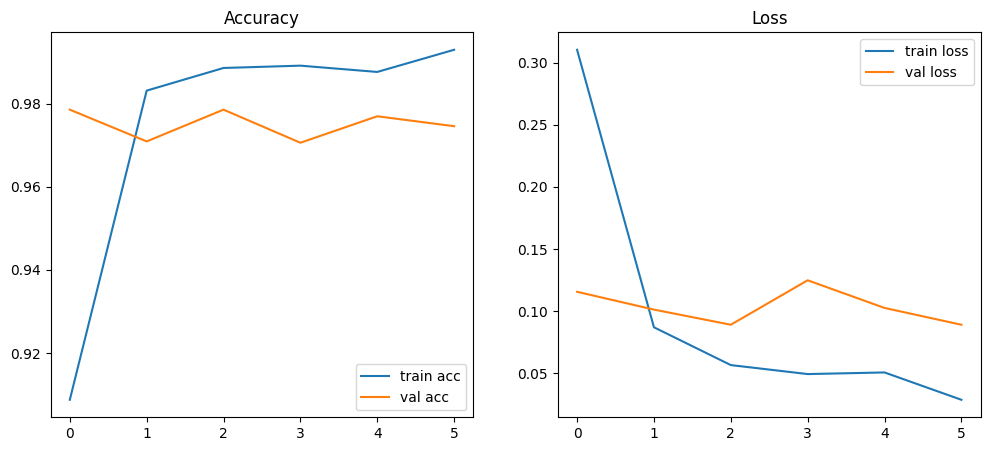

246/246 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step
              precision    recall  f1-score   support

         ham       0.96      0.98      0.97      4274
        spam       0.98      0.96      0.97      3584

    accuracy                           0.97      7858
   macro avg       0.97      0.97      0.97      7858
weighted avg       0.97      0.97      0.97      7858

Confusion Matrix:
 [[4203   71]
 [ 159 3425]]


In [ ]:

# INSTALL
!pip install -q tensorflow pandas scikit-learn nltk matplotlib
!pip install -q tensorflow pandas scikit-learn nltk matplotlib python-dotenv

# IMPORT
import pandas as pd, numpy as np, re, pickle, matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, Bidirectional, LSTM, Layer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# NLP SETUP
nltk.download("stopwords")
nltk.download("wordnet")
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


# LOAD DATASETS
sms = pd.read_csv("SMSSpamCollection", sep="\t", names=["label","text"])
enron = pd.read_csv("enron_spam_data.csv").rename(columns={"Spam/Ham":"label","Message":"text"})
data = pd.concat([sms,enron], ignore_index=True)


# CLEAN TEXT
def clean_text(t):
    t = str(t).lower()
    flags = []
    if "http" in t: flags.append("__HAS_URL__")
    if re.search(r"(verify|confirm|update|login)", t): flags.append("__SECURITY__")
    if re.search(r"(account|bank|payment|parcel|delivery)", t): flags.append("__FINANCE__")
    if re.search(r"\d{4,}", t): flags.append("__LONGNUM__")
    t = re.sub(r"<.*?>", " ", t)
    t = re.sub(r"[^a-z0-9:/\. ]", " ", t)
    t = re.sub(r"\s+", " ", t)
    tokens = [lemmatizer.lemmatize(w) for w in t.split() if w not in stop_words and len(w) > 2]
    return " ".join(tokens) + " " + " ".join(flags)

data["clean"] = data["text"].apply(clean_text)


# TOKENIZE
MAX_WORDS = 30000
MAX_LEN = 200
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(data["clean"])
X = pad_sequences(tokenizer.texts_to_sequences(data["clean"]), maxlen=MAX_LEN)

le = LabelEncoder()
y = le.fit_transform(data["label"])
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)


# ATTENTION LAYER
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1],1), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1],1), initializer="zeros", trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)


# MODEL
input_seq = Input(shape=(MAX_LEN,))
x = Embedding(MAX_WORDS, 128, input_length=MAX_LEN)(input_seq)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Bidirectional(LSTM(32, return_sequences=True))(x)
x = Attention()(x)
x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=input_seq, outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


# TRAINING
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.2, callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])


# PLOT TRAINING
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()
plt.show()


# EVALUATION
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=le.classes_))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


# SAVE MODEL & TOKENIZER
model.save("spam_model_ideal.keras")
pickle.dump(tokenizer, open("tokenizer_ideal.pkl","wb"))


In [ ]:

# IMPORT
import re, pickle
import tensorflow as tf
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Layer
from telegram import Update
from telegram.ext import (
    ApplicationBuilder,
    CommandHandler,
    MessageHandler,
    ContextTypes,
    filters
)

# NLP SETUP
nltk.download("stopwords")
nltk.download("wordnet")
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

MAX_LEN = 200


# CLEAN TEXT
def clean_text(t):
    t = str(t).lower()
    flags = []
    if "http" in t: flags.append("__HAS_URL__")
    if re.search(r"(verify|confirm|update|login)", t): flags.append("__SECURITY__")
    if re.search(r"(account|bank|payment|parcel|delivery)", t): flags.append("__FINANCE__")
    if re.search(r"\d{4,}", t): flags.append("__LONGNUM__")
    t = re.sub(r"<.*?>", " ", t)
    t = re.sub(r"[^a-z0-9:/\. ]", " ", t)
    t = re.sub(r"\s+", " ", t)
    tokens = [
        lemmatizer.lemmatize(w)
        for w in t.split()
        if w not in stop_words and len(w) > 2
    ]
    return " ".join(tokens) + " " + " ".join(flags)


# ATTENTION LAYER
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super(Attention, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(
            tf.keras.backend.dot(x, self.W) + self.b
        )
        a = tf.keras.backend.softmax(e, axis=1)
        return tf.keras.backend.sum(x * a, axis=1)

# LOAD MODEL & TOKENIZER
model = tf.keras.models.load_model(
    "spam_model_ideal.keras",
    custom_objects={"Attention": Attention}
)

tokenizer = pickle.load(open("tokenizer_ideal.pkl", "rb"))


# PREDICT FUNCTION
def predict_spam(text):
    clean = clean_text(text)
    seq = tokenizer.texts_to_sequences([clean])
    pad = pad_sequences(seq, maxlen=MAX_LEN)
    prob = model.predict(pad, verbose=0)[0][0]
    return prob

# TELEGRAM HANDLERS
async def start(update: Update, context: ContextTypes.DEFAULT_TYPE):
    await update.message.reply_text(
        "🤖 Надішли текст повідомлення — я визначу, SPAM це чи ні."
    )

async def handle_message(update: Update, context: ContextTypes.DEFAULT_TYPE):
    text = update.message.text
    prob = predict_spam(text)

    if prob >= 0.5:
        percent = int(prob * 100)
        reply = f"🚨 PHISHING / SPAM ({percent}%)"
    else:
        percent = int((1 - prob) * 100)
        reply = f"✅ SAFE ({percent}%)"

    await update.message.reply_text(reply)


# RUN BOT
import os
from dotenv import load_dotenv
load_dotenv()
TOKEN = os.getenv("TELEGRAM_BOT_TOKEN")

app = ApplicationBuilder().token(TOKEN).build()
app.add_handler(CommandHandler("start", start))
app.add_handler(MessageHandler(filters.TEXT & ~filters.COMMAND, handle_message))

print("🤖 Telegram bot is running...")
app.run_polling()
